# ============================================================
# NOTEBOOK: match_web_v2.ipynb
# Web — Matching entre CIC, Nemea, Tstat y Tshark
# Basado en match_recon_v2.ipynb + particularidades de Web
# ============================================================
#
# PARTICULARIDADES WEB (igual que Recon):
#   1. Nemea: IPs pueden venir sin puntos → reconstruir_ip
#   2. Nemea: timestamps con coma decimal → .str.replace(',','.')
#   3. Nemea: subtipos mezclados en un único CSV → etiqueta unificada a 'Web'
#   4. CIC / Tstat / Tshark: múltiples CSVs en carpeta → glob
# ============================================================

In [1]:
# ============================================================
# CELDA 0 — IMPORTS GLOBALES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("\u2713 Imports OK")
print(f"  pandas:  {pd.__version__}")
print(f"  numpy:   {np.__version__}")

✓ Imports OK
  pandas:  2.2.0
  numpy:   1.26.4


In [2]:
# ============================================================
# CELDA 0.1 — FUNCIÓN reconstruir_ip
# PARTICULARIDAD WEB: Nemea a veces guarda IPs sin puntos
# ============================================================

def reconstruir_ip(ip):
    if pd.isna(ip):
        return ip
    s = str(ip).strip()
    if "." in s:
        return s
    if not s.isdigit():
        return s
    resultados = []
    def backtrack(resto, partes):
        if len(partes) == 4:
            if resto == "":
                resultados.append(partes[:])
            return
        for i in range(1, 4):
            if i > len(resto):
                break
            trozo = resto[:i]
            if len(trozo) > 1 and trozo[0] == "0":
                continue
            valor = int(trozo)
            if 0 <= valor <= 255:
                partes.append(trozo)
                backtrack(resto[i:], partes)
                partes.pop()
    backtrack(s, [])
    if resultados:
        return ".".join(resultados[0])
    return s

print("Test reconstruir_ip:")
print(f"  '192168001001' \u2192 {reconstruir_ip('192168001001')}")
print(f"  '192.168.0.1'  \u2192 {reconstruir_ip('192.168.0.1')}  (ya tiene puntos)")
print(f"  '10001001'     \u2192 {reconstruir_ip('10001001')}")

Test reconstruir_ip:
  '192168001001' → 192168001001
  '192.168.0.1'  → 192.168.0.1  (ya tiene puntos)
  '10001001'     → 100.0.100.1


# CICFlowMeter

In [3]:
# ============================================================
# CELDA 1.1 — CARGA DE CIC
# Web tiene varios subtipos de CSV en la carpeta → glob
# ============================================================

RUTA_CIC = Path("/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosCIC/Web")

print(f"Ruta CIC: {RUTA_CIC}")
print(f"Existe:   {RUTA_CIC.exists()}")
print()

csv_files = sorted(RUTA_CIC.glob("*.csv"))
print(f"CSVs encontrados: {len(csv_files)}")

if not csv_files:
    raise FileNotFoundError(f"No se encontraron CSVs en: {RUTA_CIC}")

dfs = []
for f in csv_files:
    df_temp = pd.read_csv(f, low_memory=False)
    df_temp["archivo_origen"] = f.stem
    dfs.append(df_temp)
    print(f"  \u2713 {f.name:50s} \u2192 {len(df_temp):>8,} filas")

df_cic = pd.concat(dfs, ignore_index=True)

print()
print(f"Shape total CIC: {df_cic.shape}")
print(f"NaNs totales:    {df_cic.isnull().sum().sum():,}")

Ruta CIC: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosCIC/Web
Existe:   True

CSVs encontrados: 6
  ✓ Backdoor_Malware.pcap_Flow.csv                     →    2,848 filas
  ✓ BrowserHijacking.pcap_Flow.csv                     →    3,289 filas
  ✓ CommandInjection.pcap_Flow.csv                     →    4,035 filas
  ✓ SqlInjection.pcap_Flow.csv                         →    6,603 filas
  ✓ Uploading_Attack.pcap_Flow.csv                     →    1,348 filas
  ✓ XSS.pcap_Flow.csv                                  →    3,377 filas

Shape total CIC: (21500, 85)
NaNs totales:    1


In [4]:
# ============================================================
# CELDA 1.2 — LIMPIEZA Y NORMALIZACIÓN CIC
# ============================================================

df_cic["Timestamp"] = (
    df_cic["Timestamp"].astype(str)
    .str.replace(" p. m.", " PM", regex=False)
    .str.replace(" a. m.", " AM", regex=False)
    .str.strip()
)
df_cic["Timestamp"] = pd.to_datetime(
    df_cic["Timestamp"], format="%d/%m/%Y %I:%M:%S %p", errors="coerce"
)

nat_count = df_cic["Timestamp"].isna().sum()
print(f"NaT en Timestamp: {nat_count}")
if nat_count > 0:
    df_cic = df_cic.dropna(subset=["Timestamp"]).reset_index(drop=True)

df_cic["Protocol"]      = pd.to_numeric(df_cic["Protocol"],      errors="coerce").fillna(0).astype(int)
df_cic["Src Port"]      = pd.to_numeric(df_cic["Src Port"],      errors="coerce").fillna(0).astype(int)
df_cic["Dst Port"]      = pd.to_numeric(df_cic["Dst Port"],      errors="coerce").fillna(0).astype(int)
df_cic["Flow Duration"] = pd.to_numeric(df_cic["Flow Duration"], errors="coerce")

print(f"\nShape CIC limpio: {df_cic.shape}")
print(f"\nRango temporal CIC:")
print(f"  Min: {df_cic['Timestamp'].min()}")
print(f"  Max: {df_cic['Timestamp'].max()}")
print(f"\nDistribución por protocolo:")
print(df_cic["Protocol"].value_counts().to_string())
print(f"\nDistribución por subtipo (archivo origen):")
print(df_cic["archivo_origen"].value_counts().to_string())

NaT en Timestamp: 0

Shape CIC limpio: (21500, 85)

Rango temporal CIC:
  Min: 2022-10-03 19:17:00
  Max: 2023-02-14 18:05:00

Distribución por protocolo:
Protocol
17    12581
6      8336
0       583

Distribución por subtipo (archivo origen):
archivo_origen
SqlInjection.pcap_Flow        6603
CommandInjection.pcap_Flow    4035
XSS.pcap_Flow                 3377
BrowserHijacking.pcap_Flow    3289
Backdoor_Malware.pcap_Flow    2848
Uploading_Attack.pcap_Flow    1348


In [5]:
# ============================================================
# CELDA 1.3 — KEY BASE Y TIME_SEC CIC
# ============================================================

df_cic["time_sec"]    = df_cic["Timestamp"].dt.floor("s")
df_cic["flow_dur_ms"] = (df_cic["Flow Duration"] / 1000).round().astype("Int64")

df_cic["key_base"] = list(zip(
    df_cic["Src IP"].astype(str),
    df_cic["Src Port"].astype(str),
    df_cic["Dst IP"].astype(str),
    df_cic["Dst Port"].astype(str),
    df_cic["Protocol"].astype(str),
    df_cic["time_sec"].astype(str)
))

df_cic["key_exact"] = list(zip(
    df_cic["Src IP"].astype(str),
    df_cic["Src Port"].astype(str),
    df_cic["Dst IP"].astype(str),
    df_cic["Dst Port"].astype(str),
    df_cic["Protocol"].astype(str),
    df_cic["time_sec"].astype(str),
    df_cic["flow_dur_ms"].astype(str)
))

print(f"Shape CIC: {df_cic.shape}")
print(f"Claves base únicas: {df_cic['key_base'].nunique():,}")

Shape CIC: (21500, 89)
Claves base únicas: 20,806


In [6]:
# ============================================================
# CELDA 1.4 — ANÁLISIS DE COLISIONES CIC
# ============================================================

conteo          = df_cic.groupby("key_base").size()
total_claves    = len(conteo)
claves_unicas   = (conteo == 1).sum()
claves_colision = (conteo > 1).sum()
flujos_colision = conteo[conteo > 1].sum()
pct_colision    = round(claves_colision / total_claves * 100, 2)

print("=" * 60)
print("ANÁLISIS DE COLISIONES CIC — Web")
print("=" * 60)
print(f"  Total filas:                 {len(df_cic):,}")
print(f"  Total claves base únicas:    {total_claves:,}")
print(f"  Claves sin colisión:         {claves_unicas:,}  ({round(claves_unicas/total_claves*100,2)}%)")
print(f"  Claves con colisión:         {claves_colision:,}  ({pct_colision}%)")
print(f"  Flujos afectados:            {flujos_colision:,}")
print()
if pct_colision < 1:
    print(f"  \u2192 \u2713 SEGURO ({pct_colision}% colisiones)")
elif pct_colision < 5:
    print(f"  \u2192 ~ ACEPTABLE ({pct_colision}% colisiones)")
else:
    print(f"  \u2192 \u2717 RIESGO ({pct_colision}% colisiones)")

if claves_colision > 0:
    print("\n  Ejemplos de colisión:")
    for k in conteo[conteo > 1].index[:3]:
        df_col = df_cic[df_cic["key_base"] == k]
        print(f"\n  Clave: {k}")
        print(df_col[["Src IP","Src Port","Dst IP","Dst Port",
                       "Protocol","Timestamp","Flow Duration"]].to_string(index=False))

ANÁLISIS DE COLISIONES CIC — Web
  Total filas:                 21,500
  Total claves base únicas:    20,806
  Claves sin colisión:         20,113  (96.67%)
  Claves con colisión:         693  (3.33%)
  Flujos afectados:            1,387

  → ~ ACEPTABLE (3.33% colisiones)

  Ejemplos de colisión:

  Clave: ('108.138.125.194', '80', '192.168.137.234', '52794', '6', '2022-10-03 19:18:27')
         Src IP  Src Port          Dst IP  Dst Port  Protocol           Timestamp  Flow Duration
108.138.125.194        80 192.168.137.234     52794         6 2022-10-03 19:18:27         345517
108.138.125.194        80 192.168.137.234     52794         6 2022-10-03 19:18:27         441779

  Clave: ('13.225.196.108', '443', '192.168.137.206', '45174', '6', '2022-10-03 20:08:36')
        Src IP  Src Port          Dst IP  Dst Port  Protocol           Timestamp  Flow Duration
13.225.196.108       443 192.168.137.206     45174         6 2022-10-03 20:08:36          30584
13.225.196.108       443 192.168.1

# NEMEA

In [7]:
# ============================================================
# CELDA 2.1 — CARGA DE NEMEA
# Web: CSV único; columna final es la etiqueta (valor 'Web')
# Se detecta dinámicamente como última columna del CSV
# ============================================================

RUTA_NEMEA = Path("/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosNEMEA/Web/Web_Nemea.csv")
print(f"Ruta Nemea: {RUTA_NEMEA}")
print(f"Existe:     {RUTA_NEMEA.exists()}")

df_nemea = pd.read_csv(RUTA_NEMEA, low_memory=False)

# Detectar dinámicamente la columna de etiqueta (última columna)
col_etiqueta_nemea = df_nemea.columns[-1]
print(f"\nColumna de etiqueta detectada: '{col_etiqueta_nemea}'")

print(f"\nShape Nemea: {df_nemea.shape}")
print(f"NaNs:        {df_nemea.isnull().sum().sum():,}")
print(f"\nPrimeras columnas: {df_nemea.columns.tolist()[:10]}")
print(f"\nDistribución por protocolo:")
print(df_nemea["uint8 PROTOCOL"].value_counts().to_string())
print(f"\nDistribución por etiqueta ({col_etiqueta_nemea}):")
print(df_nemea[col_etiqueta_nemea].value_counts().to_string())

Ruta Nemea: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosNEMEA/Web/Web_Nemea.csv
Existe:     True

Columna de etiqueta detectada: 'LABEL'

Shape Nemea: (19495, 204)
NaNs:        58,368

Primeras columnas: ['ipaddr DST_IP', 'ipaddr SRC_IP', 'uint64 BYTES', 'uint64 BYTES_REV', 'uint64 FLOW_ID', 'uint64 LINK_BIT_FIELD', 'uint64 QUIC_TOKEN_LENGTH', 'uint64 TCP_OPT', 'uint64 TCP_OPT_REV', 'time TIME_FIRST']

Distribución por protocolo:
uint8 PROTOCOL
17    12703
6      5831
1       640
58      242
2        79

Distribución por etiqueta (LABEL):
LABEL
Web    19495


In [8]:
# ============================================================
# CELDA 2.2 — LIMPIEZA Y NORMALIZACIÓN NEMEA
# PARTICULARIDADES WEB:
#   - IPs pueden venir sin puntos → reconstruir_ip
#   - Timestamps con coma decimal → .str.replace(',', '.')
# ============================================================

col_src_ip   = "ipaddr SRC_IP"
col_dst_ip   = "ipaddr DST_IP"
col_src_port = "uint16 SRC_PORT"
col_dst_port = "uint16 DST_PORT"
col_protocol = "uint8 PROTOCOL"
col_t_first  = "time TIME_FIRST"
col_t_last   = "time TIME_LAST"

df_nemea[col_src_ip] = df_nemea[col_src_ip].astype(str).str.strip()
df_nemea[col_dst_ip] = df_nemea[col_dst_ip].astype(str).str.strip()

df_nemea["SRC_IP_norm"] = df_nemea[col_src_ip].apply(reconstruir_ip)
df_nemea["DST_IP_norm"] = df_nemea[col_dst_ip].apply(reconstruir_ip)

n_src_sin_punto = (~df_nemea[col_src_ip].str.contains(".", regex=False)).sum()
n_dst_sin_punto = (~df_nemea[col_dst_ip].str.contains(".", regex=False)).sum()
print(f"IPs SRC sin punto (antes de reconstruir): {n_src_sin_punto:,}")
print(f"IPs DST sin punto (antes de reconstruir): {n_dst_sin_punto:,}")
print()
print("Muestra de reconstrucción:")
print(df_nemea[[col_src_ip, "SRC_IP_norm", col_dst_ip, "DST_IP_norm"]].head(5).to_string())

df_nemea["TIME_FIRST_limpio"] = df_nemea[col_t_first].astype(str).str.replace(",", ".", regex=False)
df_nemea["TIME_LAST_limpio"]  = df_nemea[col_t_last].astype(str).str.replace(",", ".", regex=False)

df_nemea["TIME_FIRST_dt"] = pd.to_datetime(
    df_nemea["TIME_FIRST_limpio"], format="%Y-%m-%dT%H:%M:%S.%f", errors="coerce"
)
df_nemea["TIME_LAST_dt"] = pd.to_datetime(
    df_nemea["TIME_LAST_limpio"], format="%Y-%m-%dT%H:%M:%S.%f", errors="coerce"
)

df_nemea["TIME_FIRST_utc2"] = df_nemea["TIME_FIRST_dt"] + pd.Timedelta(hours=2)
df_nemea["TIME_LAST_utc2"]  = df_nemea["TIME_LAST_dt"]  + pd.Timedelta(hours=2)

df_nemea["flow_dur_us"] = (
    (df_nemea["TIME_LAST_utc2"] - df_nemea["TIME_FIRST_utc2"])
    .dt.total_seconds() * 1_000_000
).round().astype("Int64")
df_nemea["flow_dur_ms"] = (df_nemea["flow_dur_us"] / 1000).round().astype("Int64")

df_nemea[col_protocol] = pd.to_numeric(
    df_nemea[col_protocol], errors="coerce"
).fillna(0).astype(int)

print(f"\nShape Nemea: {df_nemea.shape}")
print(f"NaT en TIME_FIRST_dt: {df_nemea['TIME_FIRST_dt'].isna().sum()}")
print(f"NaT en TIME_LAST_dt:  {df_nemea['TIME_LAST_dt'].isna().sum()}")
print(f"\nRango temporal Nemea (UTC+2):")
print(f"  Min TIME_FIRST: {df_nemea['TIME_FIRST_utc2'].min()}")
print(f"  Max TIME_LAST:  {df_nemea['TIME_LAST_utc2'].max()}")
print(f"\nRango CIC:")
print(f"  Min: {df_cic['Timestamp'].min()}")
print(f"  Max: {df_cic['Timestamp'].max()}")

IPs SRC sin punto (antes de reconstruir): 759
IPs DST sin punto (antes de reconstruir): 759

Muestra de reconstrucción:
     ipaddr SRC_IP      SRC_IP_norm    ipaddr DST_IP      DST_IP_norm
0  192.168.137.187  192.168.137.187    3.208.160.215    3.208.160.215
1   192.168.137.41   192.168.137.41   157.249.81.141   157.249.81.141
2  192.168.137.208  192.168.137.208          8.8.4.4          8.8.4.4
3   192.168.137.41   192.168.137.41    192.168.137.1    192.168.137.1
4   192.168.137.75   192.168.137.75  255.255.255.255  255.255.255.255

Shape Nemea: (19495, 214)
NaT en TIME_FIRST_dt: 0
NaT en TIME_LAST_dt:  0

Rango temporal Nemea (UTC+2):
  Min TIME_FIRST: 2022-10-03 19:17:00.500922
  Max TIME_LAST:  2023-02-14 19:05:00.495411

Rango CIC:
  Min: 2022-10-03 19:17:00
  Max: 2023-02-14 18:05:00


In [9]:
# ============================================================
# CELDA 2.3 — KEY BASE Y MATCHING CIC ∩ NEMEA
# ============================================================

df_nemea["time_sec"] = df_nemea["TIME_FIRST_utc2"].dt.floor("s")

df_nemea["key_base_dir"] = list(zip(
    df_nemea["SRC_IP_norm"].astype(str),
    df_nemea[col_src_port].astype(str),
    df_nemea["DST_IP_norm"].astype(str),
    df_nemea[col_dst_port].astype(str),
    df_nemea[col_protocol].astype(str),
    df_nemea["time_sec"].astype(str)
))
df_nemea["key_base_inv"] = list(zip(
    df_nemea["DST_IP_norm"].astype(str),
    df_nemea[col_dst_port].astype(str),
    df_nemea["SRC_IP_norm"].astype(str),
    df_nemea[col_src_port].astype(str),
    df_nemea[col_protocol].astype(str),
    df_nemea["time_sec"].astype(str)
))
df_nemea["key_exact_dir"] = list(zip(
    df_nemea["SRC_IP_norm"].astype(str),
    df_nemea[col_src_port].astype(str),
    df_nemea["DST_IP_norm"].astype(str),
    df_nemea[col_dst_port].astype(str),
    df_nemea[col_protocol].astype(str),
    df_nemea["time_sec"].astype(str),
    df_nemea["flow_dur_ms"].astype(str)
))
df_nemea["key_exact_inv"] = list(zip(
    df_nemea["DST_IP_norm"].astype(str),
    df_nemea[col_dst_port].astype(str),
    df_nemea["SRC_IP_norm"].astype(str),
    df_nemea[col_src_port].astype(str),
    df_nemea[col_protocol].astype(str),
    df_nemea["time_sec"].astype(str),
    df_nemea["flow_dur_ms"].astype(str)
))

cic_keys_base  = set(df_cic["key_base"])
cic_keys_exact = set(df_cic["key_exact"])

nemea_base_dir  = set(df_nemea["key_base_dir"])
nemea_base_inv  = set(df_nemea["key_base_inv"])
nemea_exact_dir = set(df_nemea["key_exact_dir"])
nemea_exact_inv = set(df_nemea["key_exact_inv"])

match_nemea_base  = cic_keys_base  & (nemea_base_dir  | nemea_base_inv)
match_nemea_exact = cic_keys_exact & (nemea_exact_dir | nemea_exact_inv)

print("=" * 60)
print("MATCHING CIC \u2229 NEMEA — Web")
print("=" * 60)
print(f"  CIC total flujos:            {len(df_cic):,}")
print(f"  Nemea total flujos:          {len(df_nemea):,}")
print(f"  CIC claves base únicas:      {len(cic_keys_base):,}")
print(f"  Nemea claves base únicas:    {len(nemea_base_dir):,}")
print()
print(f"  Match BASE (sin duración):   {len(match_nemea_base):,}")
print(f"  Match EXACTO (con dur. ms):  {len(match_nemea_exact):,}")
print(f"  Diferencia:                  {len(match_nemea_base) - len(match_nemea_exact):,}")
print()
print(f"  % match base sobre CIC:      {round(len(match_nemea_base)/len(cic_keys_base)*100,2)}%")
print(f"  % match exacto sobre CIC:    {round(len(match_nemea_exact)/len(cic_keys_base)*100,2)}%")

MATCHING CIC ∩ NEMEA — Web
  CIC total flujos:            21,500
  Nemea total flujos:          19,495
  CIC claves base únicas:      20,806
  Nemea claves base únicas:    19,495

  Match BASE (sin duración):   5,040
  Match EXACTO (con dur. ms):  3,007
  Diferencia:                  2,033

  % match base sobre CIC:      24.22%
  % match exacto sobre CIC:    14.45%


# TSTAT

In [11]:
# ============================================================
# CELDA 3.1 — CARGA DE TSTAT
# Web tiene varios subtipos → glob igual que CIC
# ============================================================

RUTA_TSTAT = Path("/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTstat/CSV/Web")
print(f"Ruta Tstat: {RUTA_TSTAT}")
print(f"Existe:     {RUTA_TSTAT.exists()}")
print()

csv_files_tstat = sorted(RUTA_TSTAT.glob("*.csv"))
print(f"CSVs encontrados: {len(csv_files_tstat)}")

dfs_tstat = []
for f in csv_files_tstat:
    df_temp = pd.read_csv(f, low_memory=False)
    dfs_tstat.append(df_temp)
    print(f"  \u2713 {f.name:40s} \u2192 {len(df_temp):>8,} filas")

df_tstat = pd.concat(dfs_tstat, ignore_index=True)

print()
print(f"Shape total Tstat: {df_tstat.shape}")
print(f"NaNs:              {df_tstat.isnull().sum().sum():,}")
print(f"\nDistribución por protocolo:")
print(df_tstat["protocolo"].value_counts().to_string())
print(f"\nFilas con first == 0: {(df_tstat['first'] == 0).sum():,}")
print(f"Filas con first > 0:  {(df_tstat['first'] > 0).sum():,}")

Ruta Tstat: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTstat/CSV/Web
Existe:     True

CSVs encontrados: 6
  ✓ Backdoor_Malware.csv                     →    1,742 filas
  ✓ BrowserHijacking.csv                     →    2,053 filas
  ✓ CommandInjection.csv                     →    2,796 filas
  ✓ SqlInjection.csv                         →    3,878 filas
  ✓ Uploading_Attack.csv                     →    1,021 filas
  ✓ XSS.csv                                  →    2,236 filas

Shape total Tstat: (13726, 138)
NaNs:              0

Distribución por protocolo:
protocolo
UDP    12020
TCP     1706

Filas con first == 0: 12,020
Filas con first > 0:  1,706


In [12]:
# ============================================================
# CELDA 3.2 — LIMPIEZA Y SEPARACIÓN TCP/UDP TSTAT
# ============================================================

df_tcp_tstat = df_tstat[df_tstat["protocolo"] == "TCP"].copy()
df_udp_tstat = df_tstat[df_tstat["protocolo"] == "UDP"].copy()

print(f"TCP total: {len(df_tcp_tstat):,}  | UDP total: {len(df_udp_tstat):,}")
print()

# ── TCP
df_tcp_tstat["first"] = pd.to_numeric(df_tcp_tstat["first"], errors="coerce")
n_antes = len(df_tcp_tstat)
df_tcp_tstat = df_tcp_tstat[df_tcp_tstat["first"] > 0].copy()
print(f"TCP válidos (first>0): {len(df_tcp_tstat):,}  (eliminados: {n_antes-len(df_tcp_tstat):,})")

df_tcp_tstat["first_dt"]    = pd.to_datetime(df_tcp_tstat["first"], unit="ms", errors="coerce")
df_tcp_tstat["first_utc2"]  = df_tcp_tstat["first_dt"] + pd.Timedelta(hours=2)
df_tcp_tstat["flow_dur_ms"] = df_tcp_tstat["durat"].round().astype("Int64")
df_tcp_tstat["flow_dur_us"] = (df_tcp_tstat["durat"] * 1000).round().astype("Int64")
df_tcp_tstat["proto_num"]   = 6

# ── UDP
df_udp_tstat["c_first_abs"] = pd.to_numeric(df_udp_tstat["c_first_abs"], errors="coerce")
n_antes = len(df_udp_tstat)
df_udp_tstat = df_udp_tstat[df_udp_tstat["c_first_abs"] > 0].copy()
print(f"UDP válidos (c_first_abs>0): {len(df_udp_tstat):,}  (eliminados: {n_antes-len(df_udp_tstat):,})")

df_udp_tstat["first_dt"]    = pd.to_datetime(df_udp_tstat["c_first_abs"], unit="ms", errors="coerce")
df_udp_tstat["first_utc2"]  = df_udp_tstat["first_dt"] + pd.Timedelta(hours=2)
df_udp_tstat["c_durat"]     = pd.to_numeric(df_udp_tstat["c_durat"], errors="coerce").fillna(0)
df_udp_tstat["s_durat"]     = pd.to_numeric(df_udp_tstat["s_durat"], errors="coerce").fillna(0)
df_udp_tstat["flow_dur_ms"] = df_udp_tstat[["c_durat","s_durat"]].max(axis=1).round().astype("Int64")
df_udp_tstat["flow_dur_us"] = (df_udp_tstat["flow_dur_ms"] * 1000).round().astype("Int64")
df_udp_tstat["proto_num"]   = 17

print(f"\nUDP con duración > 0: {(df_udp_tstat['flow_dur_ms'] > 0).sum():,}")
print(f"UDP sin duración:     {(df_udp_tstat['flow_dur_ms'] == 0).sum():,}")

TCP total: 1,706  | UDP total: 12,020

TCP válidos (first>0): 1,706  (eliminados: 0)
UDP válidos (c_first_abs>0): 12,020  (eliminados: 0)

UDP con duración > 0: 2,892
UDP sin duración:     9,128


In [13]:
# ============================================================
# CELDA 3.3 — BASE UNIFICADA TSTAT
# ============================================================

cols_base_tstat = ["c_ip","c_port","s_ip","s_port","proto_num",
                   "first_utc2","flow_dur_us","flow_dur_ms"]

df_tstat_base = pd.concat([
    df_tcp_tstat[cols_base_tstat],
    df_udp_tstat[cols_base_tstat]
], ignore_index=True)

df_tstat_base["time_sec"] = df_tstat_base["first_utc2"].dt.floor("s")

print(f"Shape Tstat base: {df_tstat_base.shape}")
print(f"  TCP: {(df_tstat_base['proto_num']==6).sum():,}")
print(f"  UDP: {(df_tstat_base['proto_num']==17).sum():,}")
print(f"\nRango temporal Tstat (UTC+2):")
print(f"  Min: {df_tstat_base['time_sec'].min()}")
print(f"  Max: {df_tstat_base['time_sec'].max()}")
print(f"\nRango CIC:")
print(f"  Min: {df_cic['Timestamp'].min()}")
print(f"  Max: {df_cic['Timestamp'].max()}")

Shape Tstat base: (13726, 9)
  TCP: 1,706
  UDP: 12,020

Rango temporal Tstat (UTC+2):
  Min: 2022-10-03 19:17:00
  Max: 2023-02-14 19:05:00

Rango CIC:
  Min: 2022-10-03 19:17:00
  Max: 2023-02-14 18:05:00


In [14]:
# ============================================================
# CELDA 3.4 — KEY BASE Y MATCHING CIC ∩ TSTAT
# ============================================================

df_tstat_base["key_base_dir"] = list(zip(
    df_tstat_base["c_ip"].astype(str), df_tstat_base["c_port"].astype(str),
    df_tstat_base["s_ip"].astype(str), df_tstat_base["s_port"].astype(str),
    df_tstat_base["proto_num"].astype(str), df_tstat_base["time_sec"].astype(str)
))
df_tstat_base["key_base_inv"] = list(zip(
    df_tstat_base["s_ip"].astype(str), df_tstat_base["s_port"].astype(str),
    df_tstat_base["c_ip"].astype(str), df_tstat_base["c_port"].astype(str),
    df_tstat_base["proto_num"].astype(str), df_tstat_base["time_sec"].astype(str)
))

df_tstat_dur = df_tstat_base[df_tstat_base["flow_dur_ms"] > 0].copy()

df_tstat_dur["key_exact_dir"] = list(zip(
    df_tstat_dur["c_ip"].astype(str), df_tstat_dur["c_port"].astype(str),
    df_tstat_dur["s_ip"].astype(str), df_tstat_dur["s_port"].astype(str),
    df_tstat_dur["proto_num"].astype(str), df_tstat_dur["time_sec"].astype(str),
    df_tstat_dur["flow_dur_ms"].astype(str)
))
df_tstat_dur["key_exact_inv"] = list(zip(
    df_tstat_dur["s_ip"].astype(str), df_tstat_dur["s_port"].astype(str),
    df_tstat_dur["c_ip"].astype(str), df_tstat_dur["c_port"].astype(str),
    df_tstat_dur["proto_num"].astype(str), df_tstat_dur["time_sec"].astype(str),
    df_tstat_dur["flow_dur_ms"].astype(str)
))

tstat_base_keys  = set(df_tstat_base["key_base_dir"]) | set(df_tstat_base["key_base_inv"])
tstat_exact_keys = set(df_tstat_dur["key_exact_dir"]) | set(df_tstat_dur["key_exact_inv"])

match_tstat_base  = cic_keys_base  & tstat_base_keys
match_tstat_exact = cic_keys_exact & tstat_exact_keys

print("=" * 60)
print("MATCHING CIC \u2229 TSTAT — Web")
print("=" * 60)
print(f"  Tstat total flujos:          {len(df_tstat_base):,}")
print(f"  Tstat con duración > 0:      {len(df_tstat_dur):,}")
print(f"  Tstat sin duración:          {len(df_tstat_base)-len(df_tstat_dur):,}")
print()
print(f"  Match BASE (sin duración):   {len(match_tstat_base):,}")
print(f"  Match EXACTO (con dur. ms):  {len(match_tstat_exact):,}")
print(f"  Diferencia:                  {len(match_tstat_base)-len(match_tstat_exact):,}")
print()
print(f"  % match base sobre CIC:      {round(len(match_tstat_base)/len(cic_keys_base)*100,2)}%")
print(f"  % match exacto sobre CIC:    {round(len(match_tstat_exact)/len(cic_keys_base)*100,2)}%")

MATCHING CIC ∩ TSTAT — Web
  Tstat total flujos:          13,726
  Tstat con duración > 0:      4,598
  Tstat sin duración:          9,128

  Match BASE (sin duración):   3,639
  Match EXACTO (con dur. ms):  30
  Diferencia:                  3,609

  % match base sobre CIC:      17.49%
  % match exacto sobre CIC:    0.14%


# TSHARK

In [16]:
# ============================================================
# CELDA 4.1 — CARGA DE TSHARK (múltiples CSVs en carpeta)
# Web tiene varios subtipos → glob igual que CIC
# ============================================================

RUTA_TSHARK = Path("/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTshark_2/Csv/Web")
print(f"Ruta Tshark: {RUTA_TSHARK}")
print(f"Existe:      {RUTA_TSHARK.exists()}")
print()

csv_files_tshark = sorted(RUTA_TSHARK.glob("*.csv"))
print(f"CSVs encontrados: {len(csv_files_tshark)}")

dfs_tshark = []
for f in csv_files_tshark:
    df_temp = pd.read_csv(f, low_memory=False)
    df_temp["archivo_origen"] = f.stem
    dfs_tshark.append(df_temp)
    print(f"  \u2713 {f.name:40s} \u2192 {len(df_temp):>8,} filas")

df_tshark = pd.concat(dfs_tshark, ignore_index=True)

print()
print(f"Shape Tshark: {df_tshark.shape}")
print(f"NaNs:         {df_tshark.isnull().sum().sum():,}")
print(f"\nDistribución por protocolo:")
print(df_tshark["proto"].value_counts().to_string())
print(f"\nDistribución por subtipo:")
print(df_tshark["archivo_origen"].value_counts().to_string())

Ruta Tshark: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTshark_2/Csv/Web
Existe:      True

CSVs encontrados: 6
  ✓ Backdoor_Malware.csv                     →    1,902 filas
  ✓ BrowserHijacking.csv                     →    2,200 filas
  ✓ CommandInjection.csv                     →    2,736 filas
  ✓ SqlInjection.csv                         →    4,792 filas
  ✓ Uploading_Attack.csv                     →    1,028 filas
  ✓ XSS.csv                                  →    2,196 filas

Shape Tshark: (14854, 65)
NaNs:         0

Distribución por protocolo:
proto
UDP    10551
TCP     4303

Distribución por subtipo:
archivo_origen
SqlInjection        4792
CommandInjection    2736
BrowserHijacking    2200
XSS                 2196
Backdoor_Malware    1902
Uploading_Attack    1028


In [17]:
# ============================================================
# CELDA 4.2 — LIMPIEZA Y NORMALIZACIÓN TSHARK
# ============================================================

df_tshark["start_dt"]   = pd.to_datetime(df_tshark["start_epoch"], unit="s", errors="coerce")
df_tshark["start_utc2"] = df_tshark["start_dt"] + pd.Timedelta(hours=2)

df_tshark["flow_dur_us"] = (df_tshark["flow_duration_s"] * 1_000_000).round().astype("Int64")
df_tshark["flow_dur_ms"] = (df_tshark["flow_duration_s"] * 1_000).round().astype("Int64")

df_tshark["proto_num"] = pd.to_numeric(
    df_tshark["proto_num"], errors="coerce"
).fillna(0).astype(int)

n_antes = len(df_tshark)
df_tshark = df_tshark.dropna(subset=["src_ip","dst_ip"]).reset_index(drop=True)
print(f"Filas eliminadas sin IP: {n_antes - len(df_tshark):,}")

print(f"\nShape Tshark limpio: {df_tshark.shape}")
print(f"\nRango temporal Tshark (UTC+2):")
print(f"  Min: {df_tshark['start_utc2'].min()}")
print(f"  Max: {df_tshark['start_utc2'].max()}")
print(f"\nRango CIC:")
print(f"  Min: {df_cic['Timestamp'].min()}")
print(f"  Max: {df_cic['Timestamp'].max()}")

Filas eliminadas sin IP: 0

Shape Tshark limpio: (14854, 69)

Rango temporal Tshark (UTC+2):
  Min: 2022-10-03 19:17:00.500921964
  Max: 2023-02-14 19:05:00.189665079

Rango CIC:
  Min: 2022-10-03 19:17:00
  Max: 2023-02-14 18:05:00


In [18]:
# ============================================================
# CELDA 4.3 — KEY BASE Y MATCHING CIC ∩ TSHARK
# ============================================================

df_tshark["time_sec"] = df_tshark["start_utc2"].dt.floor("s")

df_tshark["key_base_dir"] = list(zip(
    df_tshark["src_ip"].astype(str), df_tshark["src_port"].astype(str),
    df_tshark["dst_ip"].astype(str), df_tshark["dst_port"].astype(str),
    df_tshark["proto_num"].astype(str), df_tshark["time_sec"].astype(str)
))
df_tshark["key_base_inv"] = list(zip(
    df_tshark["dst_ip"].astype(str), df_tshark["dst_port"].astype(str),
    df_tshark["src_ip"].astype(str), df_tshark["src_port"].astype(str),
    df_tshark["proto_num"].astype(str), df_tshark["time_sec"].astype(str)
))
df_tshark["key_exact_dir"] = list(zip(
    df_tshark["src_ip"].astype(str), df_tshark["src_port"].astype(str),
    df_tshark["dst_ip"].astype(str), df_tshark["dst_port"].astype(str),
    df_tshark["proto_num"].astype(str), df_tshark["time_sec"].astype(str),
    df_tshark["flow_dur_ms"].astype(str)
))
df_tshark["key_exact_inv"] = list(zip(
    df_tshark["dst_ip"].astype(str), df_tshark["dst_port"].astype(str),
    df_tshark["src_ip"].astype(str), df_tshark["src_port"].astype(str),
    df_tshark["proto_num"].astype(str), df_tshark["time_sec"].astype(str),
    df_tshark["flow_dur_ms"].astype(str)
))

tshark_base_keys  = set(df_tshark["key_base_dir"]) | set(df_tshark["key_base_inv"])
tshark_exact_keys = set(df_tshark["key_exact_dir"]) | set(df_tshark["key_exact_inv"])

match_tshark_base  = cic_keys_base  & tshark_base_keys
match_tshark_exact = cic_keys_exact & tshark_exact_keys

print("=" * 60)
print("MATCHING CIC \u2229 TSHARK — Web")
print("=" * 60)
print(f"  Tshark total flujos:         {len(df_tshark):,}")
print()
print(f"  Match BASE (sin duración):   {len(match_tshark_base):,}")
print(f"  Match EXACTO (con dur. ms):  {len(match_tshark_exact):,}")
print(f"  Diferencia:                  {len(match_tshark_base)-len(match_tshark_exact):,}")
print()
print(f"  % match base sobre CIC:      {round(len(match_tshark_base)/len(cic_keys_base)*100,2)}%")
print(f"  % match exacto sobre CIC:    {round(len(match_tshark_exact)/len(cic_keys_base)*100,2)}%")

MATCHING CIC ∩ TSHARK — Web
  Tshark total flujos:         14,854

  Match BASE (sin duración):   4,676
  Match EXACTO (con dur. ms):  2,871
  Diferencia:                  1,805

  % match base sobre CIC:      22.47%
  % match exacto sobre CIC:    13.8%


# Intersección las 4

In [19]:
# ============================================================
# CELDA 5.1 — INTERSECCIÓN 4 HERRAMIENTAS
# ============================================================

base_4  = match_nemea_base  & match_tstat_base  & match_tshark_base
exact_4 = match_nemea_exact & match_tstat_exact & match_tshark_exact

print("=" * 60)
print("INTERSECCIÓN 4 HERRAMIENTAS — Web")
print("=" * 60)
print(f"  CIC total claves:              {len(cic_keys_base):>8,}")
print(f"  CIC \u2229 Nemea  (base):           {len(match_nemea_base):>8,}  ({round(len(match_nemea_base)/len(cic_keys_base)*100,2)}%)")
print(f"  CIC \u2229 Tstat  (base):           {len(match_tstat_base):>8,}  ({round(len(match_tstat_base)/len(cic_keys_base)*100,2)}%)")
print(f"  CIC \u2229 Tshark (base):           {len(match_tshark_base):>8,}  ({round(len(match_tshark_base)/len(cic_keys_base)*100,2)}%)")
print()
print(f"  COMUNES 4 (base, sin dur.):    {len(base_4):>8,}  ({round(len(base_4)/len(cic_keys_base)*100,2)}%)")
print(f"  COMUNES 4 (exacto, con dur.):  {len(exact_4):>8,}  ({round(len(exact_4)/len(cic_keys_base)*100,2)}%)")
print()
print(f"  Flujos extra al quitar dur.:   {len(base_4)-len(exact_4):>8,}")

INTERSECCIÓN 4 HERRAMIENTAS — Web
  CIC total claves:                20,806
  CIC ∩ Nemea  (base):              5,040  (24.22%)
  CIC ∩ Tstat  (base):              3,639  (17.49%)
  CIC ∩ Tshark (base):              4,676  (22.47%)

  COMUNES 4 (base, sin dur.):       3,497  (16.81%)
  COMUNES 4 (exacto, con dur.):        17  (0.08%)

  Flujos extra al quitar dur.:      3,480


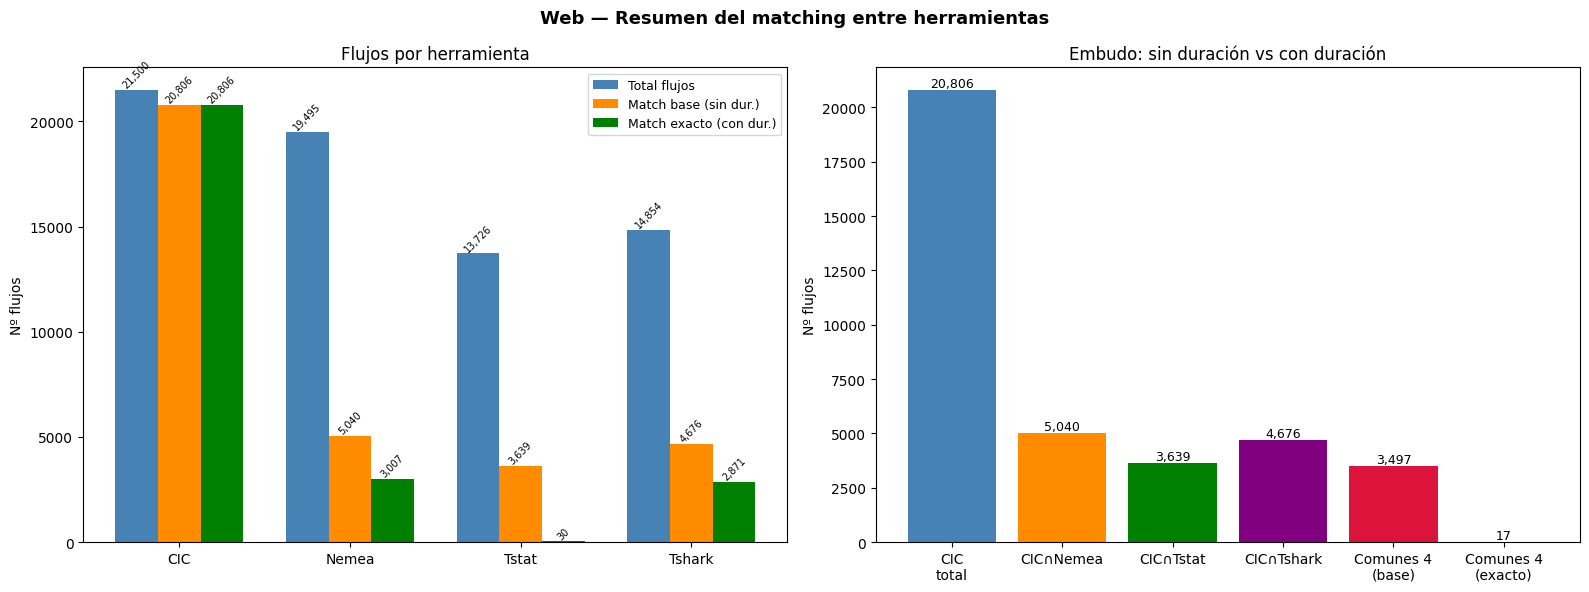

In [20]:
# ============================================================
# CELDA 5.2 — GRÁFICA RESUMEN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Web — Resumen del matching entre herramientas",
             fontsize=13, fontweight="bold")

ax1 = axes[0]
herramientas = ["CIC", "Nemea", "Tstat", "Tshark"]
totales = [len(df_cic), len(df_nemea), len(df_tstat_base), len(df_tshark)]
base    = [len(cic_keys_base), len(match_nemea_base), len(match_tstat_base), len(match_tshark_base)]
exactos = [len(cic_keys_base), len(match_nemea_exact), len(match_tstat_exact), len(match_tshark_exact)]

x, width = np.arange(len(herramientas)), 0.25
b1 = ax1.bar(x - width, totales, width, label="Total flujos",            color="steelblue")
b2 = ax1.bar(x,         base,    width, label="Match base (sin dur.)",   color="darkorange")
b3 = ax1.bar(x + width, exactos, width, label="Match exacto (con dur.)", color="green")
ax1.set_title("Flujos por herramienta")
ax1.set_ylabel("N\u00ba flujos")
ax1.set_xticks(x)
ax1.set_xticklabels(herramientas)
ax1.legend(fontsize=9)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h,
                 f"{h:,}", ha="center", va="bottom", fontsize=7, rotation=45)

ax2 = axes[1]
labels2 = ["CIC\ntotal","CIC\u2229Nemea","CIC\u2229Tstat","CIC\u2229Tshark","Comunes 4\n(base)","Comunes 4\n(exacto)"]
values2 = [len(cic_keys_base), len(match_nemea_base), len(match_tstat_base),
           len(match_tshark_base), len(base_4), len(exact_4)]
colors2 = ["steelblue","darkorange","green","purple","crimson","darkred"]
bars2 = ax2.bar(labels2, values2, color=colors2)
ax2.set_title("Embudo: sin duración vs con duración")
ax2.set_ylabel("N\u00ba flujos")
for bar, val in zip(bars2, values2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{val:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# CELDA 5.3 — EXTRACCIÓN FINAL: 4 CSVs CON TODAS LAS COLUMNAS
# ============================================================

OUTPUT_DIR = Path("/home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes/Web")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COLS_AUX_CIC = ["archivo_origen","time_sec","flow_dur_ms","key_base","key_exact"]

COLS_AUX_NEMEA = ["TIME_FIRST_limpio","TIME_LAST_limpio",
                  "TIME_FIRST_dt","TIME_LAST_dt",
                  "TIME_FIRST_utc2","TIME_LAST_utc2",
                  "SRC_IP_norm","DST_IP_norm",
                  "time_sec","flow_dur_us","flow_dur_ms",
                  "key_base_dir","key_base_inv",
                  "key_exact_dir","key_exact_inv","_key"]

COLS_AUX_TSTAT = ["first_utc2","flow_dur_us","flow_dur_ms",
                  "time_sec","key_base_dir","key_base_inv",
                  "_key","proto_num","first_dt"]

COLS_AUX_TSHARK = ["start_dt","start_utc2","flow_dur_us","flow_dur_ms",
                   "time_sec","key_base_dir","key_base_inv",
                   "key_exact_dir","key_exact_inv","proto_num","archivo_origen","_key"]

# ── NEMEA
df_nemea["_key"] = None
df_nemea.loc[df_nemea["key_base_dir"].isin(base_4), "_key"] = \
    df_nemea.loc[df_nemea["key_base_dir"].isin(base_4), "key_base_dir"]
df_nemea.loc[df_nemea["key_base_inv"].isin(base_4) & df_nemea["_key"].isna(), "_key"] = \
    df_nemea.loc[df_nemea["key_base_inv"].isin(base_4) & df_nemea["_key"].isna(), "key_base_inv"]

df_nemea_4 = df_nemea[df_nemea["_key"].isin(base_4)].copy()
df_nemea_4 = df_nemea_4.drop_duplicates(subset=["_key"], keep="first")
claves_nemea_final = set(df_nemea_4["_key"])
df_nemea_4 = df_nemea_4.drop(columns=COLS_AUX_NEMEA, errors="ignore").reset_index(drop=True)
print(f"Nemea: {len(df_nemea_4):,} filas")

# ── TSTAT
df_tstat_base["_key"] = None
df_tstat_base.loc[df_tstat_base["key_base_dir"].isin(base_4), "_key"] = \
    df_tstat_base.loc[df_tstat_base["key_base_dir"].isin(base_4), "key_base_dir"]
df_tstat_base.loc[df_tstat_base["key_base_inv"].isin(base_4) & df_tstat_base["_key"].isna(), "_key"] = \
    df_tstat_base.loc[df_tstat_base["key_base_inv"].isin(base_4) & df_tstat_base["_key"].isna(), "key_base_inv"]

idx_tstat_match = df_tstat_base[df_tstat_base["_key"].isin(base_4)].index
idx_tstat_match = idx_tstat_match[~pd.Series(idx_tstat_match).duplicated(keep="first").values]

df_tstat_full = pd.concat([df_tcp_tstat, df_udp_tstat], ignore_index=True)
df_tstat_4 = df_tstat_full.loc[idx_tstat_match].copy()
df_tstat_4["_key"] = df_tstat_base.loc[idx_tstat_match, "_key"].values
df_tstat_4 = df_tstat_4.drop_duplicates(subset=["_key"], keep="first")
claves_tstat_final = set(df_tstat_4["_key"])
df_tstat_4 = df_tstat_4.drop(columns=COLS_AUX_TSTAT, errors="ignore").reset_index(drop=True)
print(f"Tstat: {len(df_tstat_4):,} filas")

# ── TSHARK
df_tshark["_key"] = None
df_tshark.loc[df_tshark["key_base_dir"].isin(base_4), "_key"] = \
    df_tshark.loc[df_tshark["key_base_dir"].isin(base_4), "key_base_dir"]
df_tshark.loc[df_tshark["key_base_inv"].isin(base_4) & df_tshark["_key"].isna(), "_key"] = \
    df_tshark.loc[df_tshark["key_base_inv"].isin(base_4) & df_tshark["_key"].isna(), "key_base_inv"]

df_tshark_4 = df_tshark[df_tshark["_key"].isin(base_4)].copy()
df_tshark_4 = df_tshark_4.drop_duplicates(subset=["_key"], keep="first")
claves_tshark_final = set(df_tshark_4["_key"])
df_tshark_4 = df_tshark_4.drop(columns=COLS_AUX_TSHARK, errors="ignore").reset_index(drop=True)
print(f"Tshark: {len(df_tshark_4):,} filas")

# ── CIC
claves_4_real = claves_nemea_final & claves_tstat_final & claves_tshark_final
print(f"\nClaves comunes reales (en las 4): {len(claves_4_real):,}")

df_cic_4 = df_cic[df_cic["key_base"].isin(claves_4_real)].copy()
df_cic_4["Flow Duration"] = pd.to_numeric(df_cic_4["Flow Duration"], errors="coerce")
df_cic_4 = df_cic_4.sort_values("Flow Duration", ascending=False)
df_cic_4 = df_cic_4.drop_duplicates(subset=["key_base"], keep="first")
df_cic_4 = df_cic_4.drop(columns=COLS_AUX_CIC, errors="ignore").reset_index(drop=True)
print(f"CIC:  {len(df_cic_4):,} filas")

# ── Guardar
df_cic_4.to_csv(   OUTPUT_DIR / "CIC_comunes.csv",    index=False)
df_nemea_4.to_csv( OUTPUT_DIR / "Nemea_comunes.csv",  index=False)
df_tstat_4.to_csv( OUTPUT_DIR / "Tstat_comunes.csv",  index=False)
df_tshark_4.to_csv(OUTPUT_DIR / "Tshark_comunes.csv", index=False)

print()
print("=" * 60)
print("RESULTADO FINAL — Web")
print("=" * 60)
print(f"  CIC:    {len(df_cic_4):>7,} filas x {df_cic_4.shape[1]:>4} columnas")
print(f"  Nemea:  {len(df_nemea_4):>7,} filas x {df_nemea_4.shape[1]:>4} columnas")
print(f"  Tstat:  {len(df_tstat_4):>7,} filas x {df_tstat_4.shape[1]:>4} columnas")
print(f"  Tshark: {len(df_tshark_4):>7,} filas x {df_tshark_4.shape[1]:>4} columnas")
print(f"\n  Guardados en: {OUTPUT_DIR}")
print()
if len(df_cic_4) == len(df_nemea_4) == len(df_tstat_4) == len(df_tshark_4):
    print(f"  \u2713 VERIFICACIÓN CORRECTA — los 4 CSVs tienen {len(df_cic_4):,} flujos")
else:
    print(f"  \u2717 Algún CSV no coincide \u2192 revisar")

Nemea: 3,481 filas
Tstat: 3,481 filas
Tshark: 3,481 filas

Claves comunes reales (en las 4): 3,481
CIC:  3,481 filas

RESULTADO FINAL — Web
  CIC:      3,481 filas x   84 columnas
  Nemea:    3,481 filas x  204 columnas
  Tstat:    3,481 filas x  138 columnas
  Tshark:   3,481 filas x   63 columnas

  Guardados en: /home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes/Web

  ✓ VERIFICACIÓN CORRECTA — los 4 CSVs tienen 3,481 flujos


In [22]:
# ============================================================
# CELDA 5.4 — ESTANDARIZAR ETIQUETA A 'Web' EN LOS 4 CSVs
# Cada herramienta usa nombre de columna distinto y puede tener
# subtipos. Se unifican todos a la clase 'Web' para el
# clasificador ML.
# La columna de etiqueta de Nemea se detecta dinámicamente
# (última columna del CSV original, valor esperado: 'Web').
# ============================================================

LABEL_MAP = {
    "CIC":    (df_cic_4,    "Label"),
    "Nemea":  (df_nemea_4,  col_etiqueta_nemea),
    "Tshark": (df_tshark_4, "category"),
    "Tstat":  (df_tstat_4,  "etiqueta"),
}

for nombre, (df, col) in LABEL_MAP.items():
    if col in df.columns:
        antes = df[col].value_counts().to_dict()
        df[col] = "Web"
        print(f"{nombre:8s} | {col:20s} \u2192 antes: {antes}")
        print(f"{'':8s} |                       \u2192 ahora: {df[col].unique().tolist()}")
    else:
        print(f"  \u26a0 {nombre}: columna '{col}' no encontrada")

# Guardar con etiquetas actualizadas
df_cic_4.to_csv(   OUTPUT_DIR / "CIC_comunes.csv",    index=False)
df_nemea_4.to_csv( OUTPUT_DIR / "Nemea_comunes.csv",  index=False)
df_tshark_4.to_csv(OUTPUT_DIR / "Tshark_comunes.csv", index=False)
df_tstat_4.to_csv( OUTPUT_DIR / "Tstat_comunes.csv",  index=False)

print()
print("\u2713 Etiquetas actualizadas y CSVs sobreescritos")

CIC      | Label                → antes: {'SqlInjection': 3481}
         |                       → ahora: ['Web']
Nemea    | LABEL                → antes: {'Web': 3481}
         |                       → ahora: ['Web']
Tshark   | category             → antes: {'SqlInjection': 3481}
         |                       → ahora: ['Web']
Tstat    | etiqueta             → antes: {'SqlInjection': 3481}
         |                       → ahora: ['Web']

✓ Etiquetas actualizadas y CSVs sobreescritos
